## EDA (Exploratory Data Analysis)

In [1]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Load Dataset
df = pd.read_csv("../data/processed/Cleaned-Telco-Customer-Churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Service Usage & Product Impact Analysis

### 1. How does churn vary by internet service type (DSL, Fiber, No Internet)?

In [3]:
## How churn rate vary by internet service type
service_type_wise_churn_rate = df.groupby(['InternetService'])['Churn'].value_counts(normalize=True).round(2).to_frame()

service_type_wise_churn_rate

proportion
InternetService Churn            
DSL             No           0.81
                Yes          0.19
Fiber optic     No           0.58
                Yes          0.42
No              No           0.93
                Yes          0.07

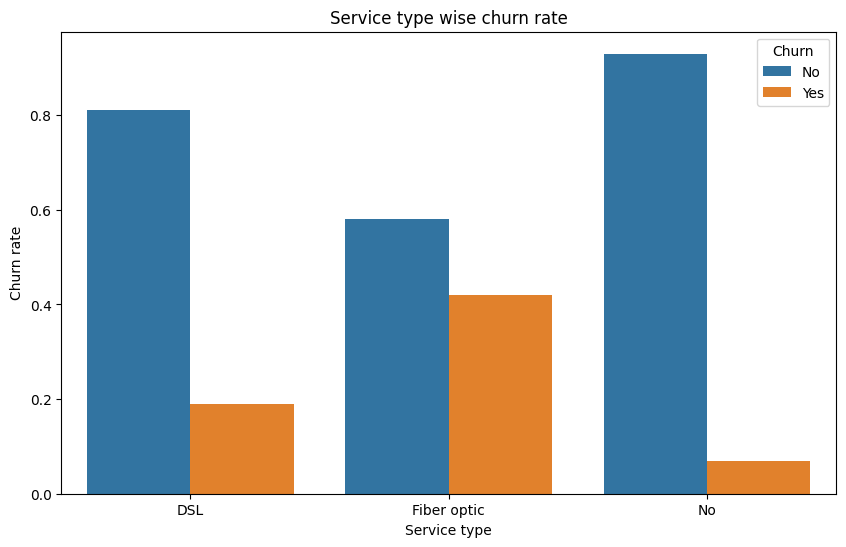

In [4]:
plt.figure(figsize=(10,6))
sns.barplot(data=service_type_wise_churn_rate, x='InternetService', y='proportion', hue='Churn')
plt.title("Service type wise churn rate")
plt.xlabel("Service type")
plt.ylabel("Churn rate");

#### Comments:
We can see that:
* Customers with Fiber optic internet service have the highest churn rate at approximately 42%, indicating that they are more likely to discontinue the service compared to other internet service types. 
* Customers with DSL internet service have a moderate churn rate of around 19%.

### 2. Do customers with fiber optic internet churn more?

**Yes**, customers with fiber optic internet do churn more compared to those with DSL or no internet service.

### 3. How do additional services (OnlineSecurity, TechSupport, Streaming) impact churn?

In [5]:
additional_services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for service in additional_services:
    df[service] = df[service].apply(lambda x: 1 if x=='Yes' else 0)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,1,0,DSL,1,0,1,0,0,0,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,0,0,DSL,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.groupby(additional_services[0])['Churn'].value_counts(normalize=True).round(2).unstack().loc[:, 'Yes']

PhoneService
0    0.25
1    0.27
Name: Yes, dtype: float64

In [7]:
## Impact of additional services on Churn rate
data = []
for service in additional_services:
    service_wise_churn_rate_for_yes = df.groupby(by=service)['Churn'].value_counts(normalize=True).round(2).unstack()['Yes']
    data.append({'Service':service, 'Has Service':service_wise_churn_rate_for_yes.index.values[0], 'Churn Rate':service_wise_churn_rate_for_yes.values[0]})
    data.append({'Service':service, 'Has Service':service_wise_churn_rate_for_yes.index.values[1], 'Churn Rate':service_wise_churn_rate_for_yes.values[1]})

service_table = pd.DataFrame(data)
service_table

,Service,Has Service,Churn Rate
0,PhoneService,0,0.25
1,PhoneService,1,0.27
2,MultipleLines,0,0.25
3,MultipleLines,1,0.29
4,OnlineSecurity,0,0.31
5,OnlineSecurity,1,0.15
6,OnlineBackup,0,0.29
7,OnlineBackup,1,0.22
8,DeviceProtection,0,0.29
9,DeviceProtection,1,0.23


In [8]:
## How much each individual service impacts (reduces/increases) the churn rate after activating it
churn_rate_diff = []
for i in range(0,16,2):
    diff = (service_table.iloc[i+1, :]['Churn Rate'] - service_table.iloc[i, :]['Churn Rate']).round(2)
    churn_rate_diff.append({'Service':service_table.iloc[i, :]['Service'],'ChurnRateIncrement':diff})
    
churn_rate_diff_df = pd.DataFrame(churn_rate_diff).sort_values(by='ChurnRateIncrement', ascending=False)
churn_rate_diff_df

,Service,ChurnRateIncrement
6,StreamingTV,0.06
7,StreamingMovies,0.06
1,MultipleLines,0.04
0,PhoneService,0.02
4,DeviceProtection,-0.06
3,OnlineBackup,-0.07
2,OnlineSecurity,-0.16
5,TechSupport,-0.16


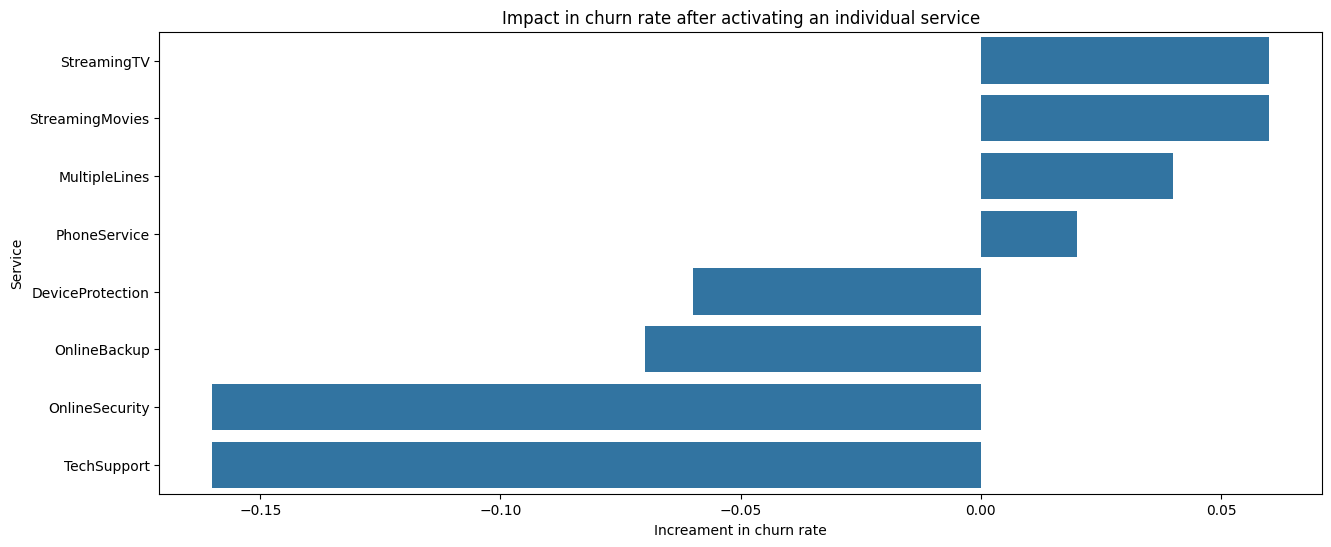

In [9]:
## Churn rate increment/decrement after activating service
plt.figure(figsize=(15,6))
sns.barplot(data=churn_rate_diff_df, y='Service', x='ChurnRateIncrement', orient='h')
plt.title("Impact in churn rate after activating an individual service")
plt.xlabel('Increament in churn rate')
plt.ylabel('Service')
plt.show()

### Comments:
We can see that:
* Additinal services like **online security**, **tech support**, and **Online backup etc**. services tend to lower the churn rate among customers.
* Customers who do not subscribe to these additional services exhibit higher churn rates compared to those who do.
* On the other hand, services like **Streaming TV** and **Streaming Movies** etc. show a slightly higher churn rate among customers.

### 4. Which services act as churn reducers?

From the above analysis it is evident that services such as ***Online Security***, ***Tech Support***, ***Online Backup*** and ***Device Protection*** act as churn reducers. Customers who subscribe to these services tend to have lower churn rates compared to those who do not.

### 5. Are customers with multiple services less likely to churn?

In [10]:
df['TotalServices'] = df[additional_services].sum(axis=1)
churn_rate = (df.groupby(['TotalServices'])['Churn']
              .apply(lambda x: ((x=='Yes').mean()*100).round(2))
              .reset_index(name='Churn_Rate')
              )
churn_rate

,TotalServices,Churn_Rate
0,0,43.75
1,1,21.17
2,2,32.83
3,3,36.48
4,4,31.38
5,5,25.61
6,6,22.50
7,7,12.44
8,8,5.31


<Figure size 1500x600 with 0 Axes>

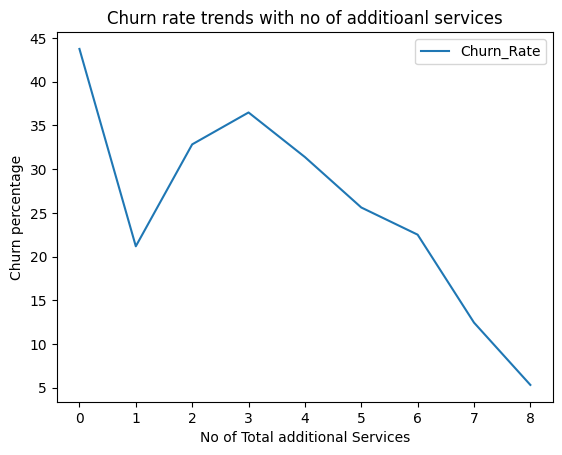

In [11]:
## Visualize the churn rate trends with no of multiple services
plt.figure(figsize=(15,6))
churn_rate.plot(kind='line', x='TotalServices', y='Churn_Rate')
plt.title("Churn rate trends with no of additioanl services")
plt.xlabel('No of Total additional Services')
plt.ylabel('Churn percentage');

#### Comments:
Customers with multiple **additional services** tend to have **lower churn rates** compared to those with fewer or no additional services. This suggests that offering a bundle of services may enhance customer satisfaction and loyalty, thereby reducing the likelihood of churn.

### 6. Best Bundle of Services to Reduce Churn

We are finding the best bundle of services based on the following criteria:

| Filter     | Rule                |
| ---------- | ------------------- |
| Churn Rate     | ≤ 15–20%            |
| Customers  | ≥ 100               |
| Complexity | ≤ 3 services        |


In [12]:
## We are already calculate churn rate differences of individual services
churn_rate_diff_df

,Service,ChurnRateIncrement
6,StreamingTV,0.06
7,StreamingMovies,0.06
1,MultipleLines,0.04
0,PhoneService,0.02
4,DeviceProtection,-0.06
3,OnlineBackup,-0.07
2,OnlineSecurity,-0.16
5,TechSupport,-0.16


#### Comments:
It is clear that additional services like *Online Security, Tech Support, Online Backup and Device Protection* are the actual churn reducers. So, bundling these services with *Internet service* can be bundled to reduce churn.


In [13]:
service_to_bundle = ["InternetService", "OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection"]

bundle_service_wise_churn = df.groupby(by=service_to_bundle)["Churn"].value_counts().unstack().reset_index()

## Add ChurnRate column
bundle_service_wise_churn['ChurnRate'] = ((bundle_service_wise_churn['Yes'] / (bundle_service_wise_churn['Yes']+bundle_service_wise_churn['No']))*100).round(2)

## Add Customers column
bundle_service_wise_churn['Customers'] = bundle_service_wise_churn['Yes']+bundle_service_wise_churn['No']

## Add TotalService column
bundle_service_wise_churn['TotalServices'] = bundle_service_wise_churn[service_to_bundle[1:]].sum(axis=1) + 1

bundle_service_wise_churn

Churn,InternetService,OnlineSecurity,TechSupport,OnlineBackup,DeviceProtection,No,Yes,ChurnRate,Customers,TotalServices
0,DSL,0,0,0,0,240,179,42.72,419,1
1,DSL,0,0,0,1,82,47,36.43,129,2
2,DSL,0,0,1,0,117,39,25.00,156,2
3,DSL,0,0,1,1,70,13,15.66,83,3
4,DSL,0,1,0,0,99,33,25.00,132,2
5,DSL,0,1,0,1,97,14,12.61,111,3
6,DSL,0,1,1,0,89,16,15.24,105,3
7,DSL,0,1,1,1,99,5,4.81,104,4
8,DSL,1,0,0,0,126,34,21.25,160,2
9,DSL,1,0,0,1,80,8,9.09,88,3


In [14]:
## Create data frame to find best services
bundle_data = []
for i in bundle_service_wise_churn.index:
    bundle_service_list = [bundle_service_wise_churn.iloc[i,:]["InternetService"]] + [x for x in bundle_service_wise_churn.iloc[i,:].iloc[1:5].index if bundle_service_wise_churn.iloc[i,:][x]==1]
    bundle_service = " + ".join(bundle_service_list)
    bundle_data.append({"Bundle":bundle_service, 'Services':bundle_service_wise_churn.iloc[i,:]['TotalServices'], 'Churn':bundle_service_wise_churn.iloc[i,:]['ChurnRate'], 'Customers':bundle_service_wise_churn.iloc[i,:]['Customers']})

bundle_service_df = pd.DataFrame(data=bundle_data)
bundle_service_df

,Bundle,Services,Churn,Customers
0,DSL,1,42.72,419
1,DSL + DeviceProtection,2,36.43,129
2,DSL + OnlineBackup,2,25.00,156
3,DSL + OnlineBackup + DeviceProtection,3,15.66,83
4,DSL + TechSupport,2,25.00,132
5,DSL + TechSupport + DeviceProtection,3,12.61,111
6,DSL + TechSupport + OnlineBackup,3,15.24,105
7,DSL + TechSupport + OnlineBackup + DeviceProte...,4,4.81,104
8,DSL + OnlineSecurity,2,21.25,160
9,DSL + OnlineSecurity + DeviceProtection,3,9.09,88


In [15]:
## Filter the data frame for findout best service
service_bundle_mask = (bundle_service_df['Churn']<=15) & (bundle_service_df['Customers']>=100) & (bundle_service_df['Services']<=3)
bundle_service_df[service_bundle_mask]

,Bundle,Services,Churn,Customers
5,DSL + TechSupport + DeviceProtection,3,12.61,111
12,DSL + OnlineSecurity + TechSupport,3,11.81,127
32,No,1,7.44,1519


#### Comments:
Based on the different criteria for identifying the best bundle of services to reduce churn is the following combination:
1. *DSL + OnlineSecurity + TechSupport* with churn rate of 11.81% and customers count of 127
2. *DSL + TechSupport + DeviceProtection*	with churn rate of 12.61% and customers count of 111

---
### Author Information
**Name:** [Apabrita Maity]  
**Date:** 2026-01-07  
**Role:** [Data Analyst | Data Scientist]

### Let's Connect!
If you have questions about this analysis or would like to collaborate, feel free to reach out:

*  **LinkedIn:** [LinkedIn](https://www.linkedin.com/in/apabritamaity/)
*  **GitHub:** [@apabritamaity](https://github.com/apabritamaity/data-analyst-portfolio)
*  **Email:** [contacttoapabrita@gmail.com](mailto:contacttoapabrita@gmail.com)